In [3]:
# Manuscript Figure 5+6 / Supp Figure 6+7 -------------------------------------
#------------------------------------------------------------------------------

library(Seurat)
#library(SeuratDisk)
library(AUCell)
library(readxl)
library(patchwork)
library(dplyr)
library(data.table)
library(ggplot2)
library(reshape2)
library(GSEABase)
library(broom)
library(ggrepel)
library(gridExtra) # Or use the `patchwork` package for flexibility
library(ComplexHeatmap)
library(circlize)

proj_dir = '/Aging/'

### directories
data_dir = '/singleCell/Ruzicka_snRNA_Seq/data/'
data_dir2 = '/Aging/Data/Anderson/snRNA_Seq/'
out_dir2 = '/Aging/Aging_Clock/Output/'

PLOTDIR <- '/Aging/Aging_Clock/Plots/'
setwd(PLOTDIR)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt


Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.uns

In [ ]:
# START HERE ------------------------------------------------------------------------------
# DOWNSTREAM ANALYSIS AFTER AUCELL

metadata <- read.csv(paste0(data_dir2,"GSE214979_metadata_AUCell_all_scores.csv"))

In [ ]:
# CORRELATION / ASSOCIATION 

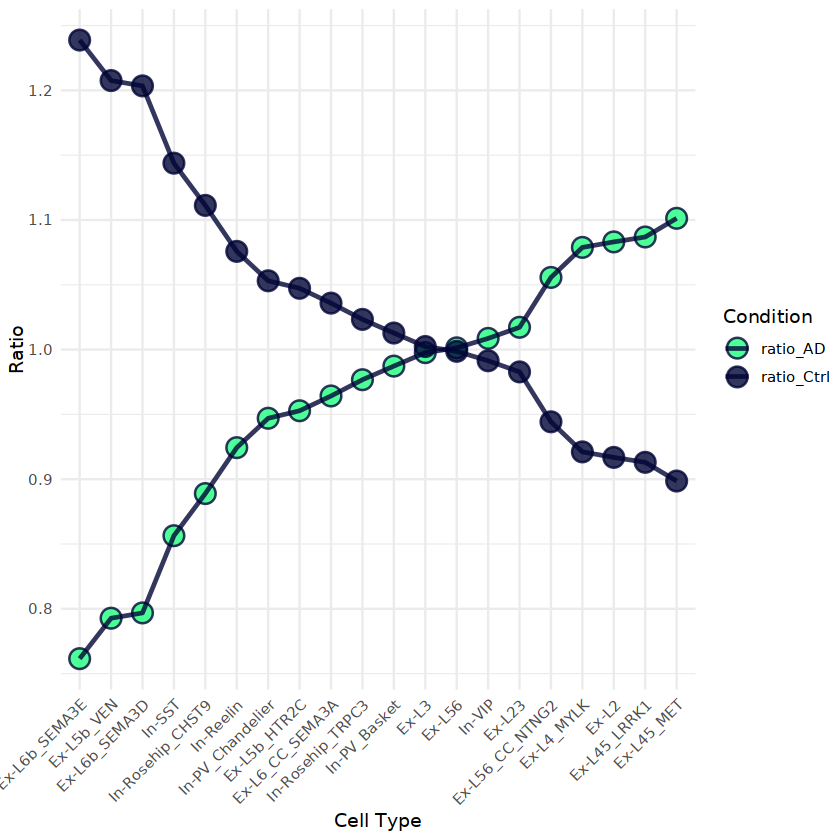

In [53]:
## Ratio vs Geneset Mean Score / Cell type

# Celltype Composition 
# AD
metadata_AD <- metadata[metadata['Status'] == 'AD',]
tbl_AD <- as.data.frame(table(unclass(metadata_AD$predicted.id)))
# Renaming columns to differentiate AD
tbl1 <- tbl_AD
colnames(tbl1)[2:ncol(tbl1)] <- paste0(colnames(tbl1)[2:ncol(tbl1)], '_AD')
# Ctrl
metadata_Ctrl <- metadata[metadata['Status'] == 'Ctrl',]
tbl_Ctrl <- as.data.frame(table(unclass(metadata_Ctrl$predicted.id)))
# Renaming columns to differentiate non-AD
tbl2 <- tbl_Ctrl
colnames(tbl2)[2:ncol(tbl2)] <- paste0(colnames(tbl2)[2:ncol(tbl2)], '_Ctrl')
# Left join AD and non-AD tables by Var1
tbl <- left_join(tbl1, tbl2, by = 'Var1')

status <- c('AD','Ctrl')
celltypes <- tbl['Var1'][[1]]

df1 <- data.frame()
for(s in 1:length(status)) {
    m_plus_n = sum(tbl$Freq_AD,tbl$Freq_Ctrl)
    k = sum(tbl[paste0('Freq_',status[s])])
    df2 <- data.frame()
    for(c in 1:length(celltypes)) {
        m = tbl[tbl$Var1==celltypes[c],][['Freq_AD']] + tbl[tbl$Var1==celltypes[c],][['Freq_Ctrl']]
        q = tbl[tbl$Var1==celltypes[c],][[paste0('Freq_',status[s])]] 
        df3 = data.frame(m_plus_n, m, k, q)
        df3$predicted.id = celltypes[c]
        
        if (c > 1) df2 = rbind(df2,df3)
        if (c == 1) df2 = df3  
                }
    colnames(df2)[c(1:4)] = paste0(colnames(df2)[c(1:4)],"_",status[s])
    if (s > 1) df1 = left_join(df1,df2, by = 'predicted.id')
    if (s == 1) df1 = df2
    }
rownames(df1) <- df1$predicted.id

# Ratio = proportion of celltype in group relative to its proprtion in total population 
# High = more prevalent in group 
# Low = less prevalent in total population 
df1$ratio_AD <- (df1$q_AD/df1$k_AD)/(df1$m_AD/df1$m_plus_n_AD)
df1$ratio_Ctrl <- (df1$q_Ctrl/df1$k_Ctrl)/(df1$m_Ctrl/df1$m_plus_n_Ctrl)
df1$FC_AD <- (df1$q_AD/df1$k_AD)/(df1$q_Ctrl/df1$k_Ctrl)
df1$FC_Ctrl <- (df1$q_Ctrl/df1$k_Ctrl)/(df1$q_AD/df1$k_AD)
df1 <- df1[,10:11]
df1$predicted.id <- rownames(df1)

##################################
##################################

# Reorder celltype based on ratio_PD
df1_long <- reshape2::melt(df1, id.vars = "predicted.id", 
                           variable.name = "Condition", 
                           value.name = "Ratio")               
df1_long$predicted.id <- factor(df1_long$predicted.id, 
                            levels = df1$predicted.id[order(df1$ratio_AD)])

PLOTDIR <- ''
#pdf(paste0(PLOTDIR, 'Scatterplot.Anderson_AD_predicted.id_composition_ratio.pdf'), width = 5, height = 5)
              
ggplot(df1_long, aes(x = predicted.id, y = Ratio, color = Condition, group = Condition, fill = Condition)) +
  geom_point(size = 5, alpha = 0.8, shape = 21, stroke = 0.8) +  # Add points with fill and outline
  geom_line(size = 1, alpha = 0.8) +  # Connect the dots with lines
  scale_color_manual(values = rep('#000435',3)) +  # Set colors for outline
  scale_fill_manual(values = c("#21FE80","#000435", "#FFFFFF")) +  # Set colors for fill
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(x = "Cell Type", y = "Ratio")
#dev.off()

##################################

In [66]:
# LM

result <- metadata %>%
  group_by(predicted.id) %>%
  summarise(across(c(geneset_sc0,geneset_sc24,
                    geneset_dd.x, can_sen.x, sen_init.x, sen_resp.x), ~ mean(.x, na.rm = TRUE)))
result <- left_join(df1, result, by='predicted.id')

# Subset data for Ctrl and AD
tbl_ctrl <- subset(metadata, Status == 'Ctrl')
tbl_ad <- subset(metadata, Status == 'AD')

result_ctrl <- tbl_ctrl %>%
  group_by(predicted.id) %>%
  summarise(across(c(geneset_sc0,geneset_sc24, geneset_dd.x, can_sen.x, sen_init.x, sen_resp.x), ~ mean(.x, na.rm = TRUE)))
result_ctrl <- result_ctrl[-which(result_ctrl$predicted.id=='Ex-NRGN'),]

result_ad <- tbl_ad %>%
  group_by(predicted.id) %>%
  summarise(across(c(geneset_sc0,geneset_sc24,geneset_dd.x, can_sen.x, sen_init.x, sen_resp.x), ~ mean(.x, na.rm = TRUE)))

result_ctrl <- left_join(df1, result_ctrl, by='predicted.id')
result_ad <- left_join(df1, result_ad, by='predicted.id')


# Function to create a plot for a given subset of data and model
create_plot <- function(data, x_var, y_var, title) {
  lm.out <- lm(as.formula(paste(y_var, "~", x_var)) , data = data)
  model_stats <- glance(lm.out)
  coeff_stats <- tidy(lm.out)
  print(coeff_stats)
  
  annotation_text <- paste0(
    "Coefficient: ", round(coeff_stats$estimate[2], 2), "\n", 
    "p-value: ", format.pval(coeff_stats$p.value[2], digits = 2), "\n",
    "Adj R²: ", round(model_stats$adj.r.squared, 2)
  )
  
  ggplot(data, aes_string(x = x_var, y = y_var)) +
    geom_point(shape = 21, color = "#FFFFFF", fill = "#000435", size = 5, stroke = 0.2, alpha = 0.8) +
    geom_smooth(method = "lm", color = "#21FE80", fill = "steelblue", alpha = 0.2, se = TRUE) +
    labs(title = title, y = 'Ratio' , x = x_var) +
    annotate(
      "text", 
      x = max(data[[x_var]]) - diff(range(data[[x_var]])) * 0.3, 
      y = max(data[[y_var]]) - diff(range(data[[y_var]])) * 0.1, 
      label = annotation_text, hjust = -0.2, vjust = 10, size = 2.5, color = "black"
    ) +
    geom_text_repel(aes(label = predicted.id), size = 3, max.overlaps = 10) +
    coord_cartesian(clip = "off") +
    theme_minimal(base_size = 14) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      axis.title = element_text(size = 10),
      axis.text = element_text(size = 10)
    )
}

# Create plots
pdf(paste0(PLOTDIR, 'ggplot.Anderson_mean_celltype_ratio_mean_no_NRGN_geneset_score.pdf'), width = 8, height = 8)
sign <- c("geneset_sc0", "geneset_sc24",'geneset_dd.x','can_sen.x', 'sen_init.x', 'sen_resp.x')
for(i in sign){
    plot1 <- create_plot(result,i, "ratio_Ctrl", paste0('Ctrl: Age Range ',min(na.omit(metadata_Ctrl$Age)),'-',max(na.omit(metadata_Ctrl$Age))))
    plot2 <- create_plot(result,i,"ratio_AD", paste0('AD: Age Range ',min(na.omit(metadata_AD$Age)),'-',max(na.omit(metadata_AD$Age)))) 
    # Arrange all plots in a grid
    grid.arrange(plot1, plot2, nrow = 2, ncol = 2)
    }
dev.off()

# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)     1.10    0.0400     27.6  3.50e-16
2 geneset_sc0    -4.59    2.28       -2.02 5.89e- 2
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.895    0.0400     22.4  1.36e-14
2 geneset_sc0    4.58     2.27        2.02 5.89e- 2


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)      1.25    0.0753     16.6  2.23e-12
2 geneset_sc24    -3.03    1.02       -2.98 8.07e- 3
# A tibble: 2 × 5
  term         estimate std.error statistic       p.value
  <chr>           <dbl>     <dbl>     <dbl>         <dbl>
1 (Intercept)     0.747    0.0752      9.94 0.00000000974
2 geneset_sc24    3.02     1.02        2.98 0.00807      


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term         estimate std.error statistic    p.value
  <chr>           <dbl>     <dbl>     <dbl>      <dbl>
1 (Intercept)      1.08     0.169     6.41  0.00000493
2 geneset_dd.x    -1.27     4.45     -0.286 0.779     
# A tibble: 2 × 5
  term         estimate std.error statistic   p.value
  <chr>           <dbl>     <dbl>     <dbl>     <dbl>
1 (Intercept)     0.916     0.169     5.42  0.0000374
2 geneset_dd.x    1.27      4.44      0.286 0.779    


...

# A tibble: 2 × 5
  term        estimate std.error statistic p.value
  <chr>          <dbl>     <dbl>     <dbl>   <dbl>
1 (Intercept)     1.19     0.432     2.76   0.0129
2 sen_init.x     -3.90    10.8      -0.362  0.721 
# A tibble: 2 × 5
  term        estimate std.error statistic p.value
  <chr>          <dbl>     <dbl>     <dbl>   <dbl>
1 (Intercept)    0.808     0.431     1.87   0.0773
2 sen_init.x     3.89     10.7       0.362  0.721 


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.910    0.0538     16.9  1.68e-12
2 sen_resp.x     9.06     3.58        2.53 2.10e- 2
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)     1.09    0.0537     20.3  7.42e-14
2 sen_resp.x     -9.05    3.58       -2.53 2.10e- 2


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

In [68]:
## Geneset Mean Score / Cell type

tbl <- metadata[,which(names(metadata) %in% c('predicted.id','Status','Age','Sex','geneset_sc0','geneset_sc24',
                                             'geneset_dd.x','can_sen.x', 'sen_init.x', 'sen_resp.x', 'cellage.x'))]

# Subset data for Ctrl and AD
tbl_ctrl <- subset(tbl, Status == 'Ctrl')
tbl_ad <- subset(tbl, Status == 'AD')

result_ctrl <- tbl_ctrl %>%
  group_by(predicted.id) %>%
  summarise(across(c(geneset_sc0,geneset_sc24, geneset_dd.x, can_sen.x, sen_init.x, sen_resp.x, cellage.x), ~ mean(.x, na.rm = TRUE)))
result_ctrl <- result_ctrl[-which(result_ctrl$predicted.id=='Ex-NRGN'),]

result_ad <- tbl_ad %>%
  group_by(predicted.id) %>%
  summarise(across(c(geneset_sc0,geneset_sc24,geneset_dd.x, can_sen.x, sen_init.x, sen_resp.x, cellage.x), ~ mean(.x, na.rm = TRUE)))
# AD -- no annotated Ex-NRGN
##################################

# Function to create a plot for a given subset of data and model
create_plot <- function(data, x_var, y_var, title) {
  lm.out <- lm(as.formula(paste(y_var, "~", x_var)) , data = data)
  model_stats <- glance(lm.out)
  coeff_stats <- tidy(lm.out)
  print(coeff_stats)
  
  annotation_text <- paste0(
    "Coefficient: ", round(coeff_stats$estimate[2], 2), "\n", 
    "p-value: ", format.pval(coeff_stats$p.value[2], digits = 2), "\n",
    "Adj R²: ", round(model_stats$adj.r.squared, 2)
  )
  
  ggplot(data, aes_string(x = x_var, y = y_var)) +
    geom_point(shape = 21, color = "#FFFFFF", fill = "#000435", size = 5, stroke = 0.2, alpha = 0.8) +
    geom_smooth(method = "lm", color = "#21FE80", fill = "steelblue", alpha = 0.2, se = TRUE) +
    labs(title = title, y = y_var , x = "Age Signature") +
    annotate(
      "text", 
      x = max(data[[x_var]]) - diff(range(data[[x_var]])) * 0.3, 
      y = max(data[[y_var]]) - diff(range(data[[y_var]])) * 0.1, 
      label = annotation_text, hjust = -0.2, vjust = 10, size = 2.5, color = "black"
    ) +
    geom_text_repel(aes(label = predicted.id), size = 3, max.overlaps = 10) +
    coord_cartesian(clip = "off") +
    theme_minimal(base_size = 14) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      axis.title = element_text(size = 10),
      axis.text = element_text(size = 10)
    )
}

# Create plots
pdf(paste0(PLOTDIR, 'ggplot.Anderson_mean_celltype_no_NRGN_geneset_score.pdf'), width = 8, height = 8)
sign <- c('geneset_dd.x','can_sen.x', 'sen_init.x', 'sen_resp.x', 'cellage.x')
for(i in sign){
    plot1 <- create_plot(result_ctrl, "geneset_sc0",i, paste0('Systemic: Ctrl')) 
    plot2 <- create_plot(result_ctrl, "geneset_sc24",i, paste0('Intrinsic: Ctrl'))
    plot3 <- create_plot(result_ad, "geneset_sc0",i, paste0('Systemic: AD'))
    plot4 <- create_plot(result_ad, "geneset_sc24",i, paste0('Intrinsic: AD'))
    # Arrange all plots in a grid
    grid.arrange(plot1, plot2, plot3, plot4, nrow = 2, ncol = 2)
    }
dev.off()

# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0350   0.00110     31.8  2.82e-17
2 geneset_sc0   0.150    0.102        1.47 1.58e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic       p.value
  <chr>           <dbl>     <dbl>     <dbl>         <dbl>
1 (Intercept)    0.0429   0.00398     10.8  0.00000000280
2 geneset_sc24  -0.111    0.0614      -1.81 0.0866       
# A tibble: 2 × 5
  term        estimate std.error statistic       p.value
  <chr>          <dbl>     <dbl>     <dbl>         <dbl>
1 (Intercept)   0.0425   0.00408    10.4   0.00000000477
2 geneset_sc0  -0.120    0.153      -0.781 0.445        
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0546   0.00432     12.6  2.21e-10
2 geneset_sc24  -0.187    0.0515      -3.62 1.94e- 3


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0247   0.00167    14.8   1.59e-11
2 geneset_sc0  -0.0241   0.154      -0.156 8.78e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0265   0.00620     4.27  0.000463
2 geneset_sc24  -0.0295   0.0956     -0.308 0.761   
# A tibble: 2 × 5
  term         estimate std.error statistic     p.value
  <chr>           <dbl>     <dbl>     <dbl>       <dbl>
1 (Intercept)  0.0249     0.00310   8.02    0.000000237
2 geneset_sc0 -0.000902   0.116    -0.00777 0.994      
# A tibble: 2 × 5
  term         estimate std.error statistic    p.value
  <chr>           <dbl>     <dbl>     <dbl>      <dbl>
1 (Intercept)    0.0266   0.00422     6.30  0.00000617
2 geneset_sc24  -0.0220   0.0503     -0.437 0.668     


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0397  0.000661    60.1   3.35e-22
2 geneset_sc0   0.0548  0.0610       0.898 3.81e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0414   0.00249    16.6   2.34e-12
2 geneset_sc24  -0.0209   0.0384     -0.543 5.94e- 1
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)  0.0400    0.00128    31.1   4.17e-17
2 geneset_sc0  0.00729   0.0481      0.152 8.81e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0403    0.00176   22.9    9.34e-15
2 geneset_sc24 -0.00159   0.0210    -0.0758 9.40e- 1


...

# A tibble: 2 × 5
  term        estimate std.error statistic      p.value
  <chr>          <dbl>     <dbl>     <dbl>        <dbl>
1 (Intercept)   0.0145   0.00150     9.67  0.0000000150
2 geneset_sc0  -0.130    0.139      -0.935 0.362       
# A tibble: 2 × 5
  term         estimate std.error statistic p.value
  <chr>           <dbl>     <dbl>     <dbl>   <dbl>
1 (Intercept)    0.0212   0.00544      3.89 0.00107
2 geneset_sc24  -0.117    0.0838      -1.40 0.179  
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0163   0.00360     4.53  0.000260
2 geneset_sc0  -0.0866   0.135      -0.641 0.529   
# A tibble: 2 × 5
  term         estimate std.error statistic p.value
  <chr>           <dbl>     <dbl>     <dbl>   <dbl>
1 (Intercept)    0.0170   0.00495     3.43  0.00300
2 geneset_sc24  -0.0345   0.0589     -0.585 0.566  


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0376  0.000815    46.1   3.84e-20
2 geneset_sc0  -0.0135  0.0752      -0.179 8.60e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0338   0.00290     11.7  7.95e-10
2 geneset_sc24   0.0580   0.0447       1.30 2.11e- 1
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)  0.0366    0.00172   21.2    3.47e-14
2 geneset_sc0  0.00442   0.0646     0.0684 9.46e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0342   0.00228     15.0  1.32e-11
2 geneset_sc24   0.0305   0.0272       1.12 2.78e- 1


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

In [33]:
## Geneset Score / Cell

# Correlation with DNA Damage
tbl <- metadata[,which(names(metadata) %in% c('predicted.id','Status','Age','Sex','geneset_sc0','geneset_sc24',
                                             'geneset_dd.x','can_sen.x', 'sen_init.x', 'sen_resp.x', 'cellage.x'))]

table(tbl$Status)
tbl1 <- subset(tbl, Status == 'AD')
table(tbl1$Status)
tbl1 <- tbl1[,which(names(tbl1) %in% c('geneset_sc0','geneset_sc24','geneset_dd.x','Age','Sex'))]

pdf(paste0(PLOTDIR, 'Heatmap.Anderson_score_cor_dd_AD.pdf'), width = 4, height = 4)
cor_matrix <- cor(tbl1[,-c(1:2)])
h1 <- Heatmap(cor_matrix, col = colorRamp2(c(-1, 0, 1), c("#000435", "#FFFFFF", "#21FE80")),
              cluster_rows = F, cluster_columns = F,
       cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            grid.text(round(cor_matrix[i, j], 2), x, y, gp = gpar(fontsize = 15, col = "#000435"))
        })
draw(h1)
dev.off()

#####################################
#####################################

# Linear Regression on DNA Damage -- Corrected for Age and Sex

# Function to create a plot for a given subset of data and model
create_plot <- function(data, x_var, y_var, title) {
  lm.out <- lm(as.formula(paste(y_var, "~", x_var, "+ Age + Sex")) , data = data)
  model_stats <- glance(lm.out)
  coeff_stats <- tidy(lm.out)
  print(coeff_stats)
  
  annotation_text <- paste0(
    "Coefficient: ", round(coeff_stats$estimate[2], 2), "\n", 
    "p-value: ", format.pval(coeff_stats$p.value[2], digits = 2), "\n",
    "Adj R²: ", round(model_stats$adj.r.squared, 2)
  )
  
  ggplot(data, aes_string(x = x_var, y = y_var)) +
    geom_point(shape = 21, color = "#FFFFFF", fill = "#000435", size = 3, stroke = 0.2, alpha = 0.8) +
    geom_smooth(method = "lm", color = "#21FE80", fill = "steelblue", alpha = 0.2, se = TRUE) +
    labs(title = title, x = "DNA Damage Signature Score", y = "Age Signature") +
    annotate(
      "text", 
      x = max(data[[x_var]]) - diff(range(data[[x_var]])) * 0.3, 
      y = max(data[[y_var]]) - diff(range(data[[y_var]])) * 0.1, 
      label = annotation_text, hjust = 0, vjust = 1, size = 5, color = "black"
    ) +
    coord_cartesian(clip = "off") +
    theme_minimal(base_size = 14) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      axis.title = element_text(size = 14),
      axis.text = element_text(size = 12)
    )
}

# Subset data for Ctrl and old
tbl_ctrl <- subset(tbl, Status == 'Ctrl')
tbl_ad <- subset(tbl, Status == 'AD')

# Exclude missing values and include relevant columns
columns_to_keep <- c('geneset_sc0', 'geneset_sc24', 'geneset_dd.x', 'Age', 'Sex')
tbl_ctrl <- na.omit(tbl_ctrl[, names(tbl_ctrl) %in% columns_to_keep])
tbl_ad <- na.omit(tbl_ad[, names(tbl_ad) %in% columns_to_keep])

# Create plots
pdf(paste0(PLOTDIR, 'ggplot.Anderson_geneset_score_dd.pdf'), width = 20, height = 20)
plot1 <- create_plot(tbl_ctrl, "geneset_dd.x", "geneset_sc0", paste0('Systemic: Ctrl - Age Range ',min(tbl_ctrl$Age),'-',max(tbl_ctrl$Age))) 
plot2 <- create_plot(tbl_ctrl, "geneset_dd.x", "geneset_sc24", paste0('Intrinsic: Ctrl - Age Range ',min(tbl_ctrl$Age),'-',max(tbl_ctrl$Age)))
plot3 <- create_plot(tbl_ad, "geneset_dd.x", "geneset_sc0", paste0('Systemic: AD - Age Range ',min(tbl_ad$Age),'-',max(tbl_ad$Age)))
plot4 <- create_plot(tbl_ad, "geneset_dd.x", "geneset_sc24", paste0('Intrinsic: AD - Age Range ',min(tbl_ad$Age),'-',max(tbl_ad$Age)))
# Arrange all plots in a grid
grid.arrange(plot1, plot2, plot3, plot4, nrow = 2, ncol = 2)
dev.off()

#####################################
#####################################

# Linear Regression on DNA Damage -- Not corrected

# Function to create a plot for a given subset of data and model
create_plot <- function(data, x_var, y_var, title) {
  lm.out <- lm(as.formula(paste(y_var, "~", x_var)) , data = data)
  model_stats <- glance(lm.out)
  coeff_stats <- tidy(lm.out)
  print(coeff_stats)
  
  annotation_text <- paste0(
    "Coefficient: ", round(coeff_stats$estimate[2], 2), "\n", 
    "p-value: ", format.pval(coeff_stats$p.value[2], digits = 2), "\n",
    "Adj R²: ", round(model_stats$adj.r.squared, 2)
  )
  
  ggplot(data, aes_string(x = x_var, y = y_var)) +
    geom_point(shape = 21, color = "#FFFFFF", fill = "#000435", size = 3, stroke = 0.2, alpha = 0.8) +
    geom_smooth(method = "lm", color = "#21FE80", fill = "steelblue", alpha = 0.2, se = TRUE) +
    labs(title = title, x = "DNA Damage Signature Score", y = "Age Signature") +
    annotate(
      "text", 
      x = max(data[[x_var]]) - diff(range(data[[x_var]])) * 0.3, 
      y = max(data[[y_var]]) - diff(range(data[[y_var]])) * 0.1, 
      label = annotation_text, hjust = 0, vjust = 1, size = 5, color = "black"
    ) +
    coord_cartesian(clip = "off") +
    theme_minimal(base_size = 14) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      axis.title = element_text(size = 14),
      axis.text = element_text(size = 12)
    )
}

# Subset data for Ctrl and old
tbl_ctrl <- subset(tbl, Status == 'Ctrl')
tbl_ad <- subset(tbl, Status == 'AD')

# Exclude missing values and include relevant columns
columns_to_keep <- c('geneset_sc0', 'geneset_sc24', 'geneset_dd.x','Age','Sex')
tbl_ctrl <- na.omit(tbl_ctrl[, names(tbl_ctrl) %in% columns_to_keep])
tbl_ad <- na.omit(tbl_ad[, names(tbl_ad) %in% columns_to_keep])

# Create plots
pdf(paste0(PLOTDIR, 'ggplot.Anderson_geneset_score_dd_uc.pdf'), width = 20, height = 20)
plot1 <- create_plot(tbl_ctrl, "geneset_dd.x", "geneset_sc0", paste0('Systemic: Ctrl - Age Range ',min(tbl_ctrl$Age),'-',max(tbl_ctrl$Age))) 
plot2 <- create_plot(tbl_ctrl, "geneset_dd.x", "geneset_sc24", paste0('Intrinsic: Ctrl - Age Range ',min(tbl_ctrl$Age),'-',max(tbl_ctrl$Age)))
plot3 <- create_plot(tbl_ad, "geneset_dd.x", "geneset_sc0", paste0('Systemic: AD - Age Range ',min(tbl_ad$Age),'-',max(tbl_ad$Age)))
plot4 <- create_plot(tbl_ad, "geneset_dd.x", "geneset_sc24", paste0('Intrinsic: AD - Age Range ',min(tbl_ad$Age),'-',max(tbl_ad$Age)))
# Arrange all plots in a grid
grid.arrange(plot1, plot2, plot3, plot4, nrow = 2, ncol = 2)
dev.off()


   AD  Ctrl 
28119 28096 


   AD 
28119 

pdf 
  2

# A tibble: 4 × 5
  term          estimate std.error statistic   p.value
  <chr>            <dbl>     <dbl>     <dbl>     <dbl>
1 (Intercept)  -0.0539   0.000868      -62.1 0        
2 geneset_dd.x  0.370    0.0101         36.7 1.36e-287
3 Age           0.000618 0.0000130      47.6 0        
4 SexM          0.0168   0.000310       54.0 0        
# A tibble: 4 × 5
  term          estimate std.error statistic   p.value
  <chr>            <dbl>     <dbl>     <dbl>     <dbl>
1 (Intercept)   0.0269   0.00129        20.9 7.35e- 96
2 geneset_dd.x -0.350    0.0150        -23.4 1.63e-119
3 Age           0.000713 0.0000193      37.0 1.14e-292
4 SexM          0.0155   0.000461       33.7 6.83e-244
# A tibble: 4 × 5
  term          estimate std.error statistic   p.value
  <chr>            <dbl>     <dbl>     <dbl>     <dbl>
1 (Intercept)   0.0823   0.00198       41.6  0        
2 geneset_dd.x -0.0272   0.0102        -2.66 7.79e-  3
3 Age          -0.000730 0.0000221    -33.0  9.48e-234
4 SexM     

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

In [ ]:
# HYPERGEOMTRIC TEST ---------------------------------------------------------------------

In [180]:
# Overrepresentation Analysis By Status

# Aging Signatures 
# Senescence+DNA Damage Signatures

# Calculating geneSet_pos and geneSet_neg 
tbl <- table(metadata$Status)
pos0 <- table(metadata$Status, metadata$geneset_pos0.y)
neg0 <- table(metadata$Status, metadata$geneset_neg0.y)
pos24 <- table(metadata$Status, metadata$geneset_pos24.y)
neg24 <- table(metadata$Status, metadata$geneset_neg24.y)
can_sen <- table(metadata$Status, metadata$can_sen.y)
sen_init <- table(metadata$Status, metadata$sen_init.y)
sen_resp <- table(metadata$Status, metadata$sen_resp.y)
dna_damage <- table(metadata$Status, metadata$geneset_dd.y)

tbl <- as.data.frame(cbind(tbl, pos0, neg0, pos24, neg24, 
                           can_sen, sen_init, sen_resp, dna_damage))
tbl$Var1 <- rownames(tbl)

direction <- c('geneset_pos0', 'geneset_neg0', 'geneset_pos24', 'geneset_neg24',
              'can_sen', 'sen_init','sen_resp','geneset_dd')
status <- c('Ctrl','AD')

df <- data.frame()
for(d in 1:length(direction)) {
    print(direction[d])
    df1 <- data.frame()
    for(s in 1:length(status)) {
        print(status[s])
        m_plus_n = sum(tbl$tbl)
        m = sum(tbl[paste0(direction[d])])
        k = tbl[tbl$Var1==status[s],][['tbl']]
        q = tbl[tbl$Var1==status[s],][[paste0(direction[d])]]
        phyper = phyper(q, m, m_plus_n - m, k, lower.tail = FALSE, log.p = FALSE)
        df2 = data.frame(m_plus_n, m, k, q, phyper)
        df2$status = status[s]
        
        if (s > 1) df1 = rbind(df1,df2)
        if (s == 1) df1 = df2 
                }
    df1 = df1[,c('status','phyper')]
    colnames(df1)[2] = paste0(direction[d])

    if (d > 1) df = left_join(df,df1, by = 'status')
    if (d == 1) df = df1
    }

counts <- tbl
phyper <- df
#write.csv(counts, paste0(out_dir2,'Anderson_status_counts.csv'))
#write.csv(phyper, paste0(out_dir2,'Anderson_status_phyper_uncorrected.csv'))

[1] "geneset_pos0"
[1] "Ctrl"
[1] "AD"
[1] "geneset_neg0"
[1] "Ctrl"
[1] "AD"
[1] "geneset_pos24"
[1] "Ctrl"
[1] "AD"
[1] "geneset_neg24"
[1] "Ctrl"
[1] "AD"
[1] "can_sen"
[1] "Ctrl"
[1] "AD"
[1] "sen_init"
[1] "Ctrl"
[1] "AD"
[1] "sen_resp"
[1] "Ctrl"
[1] "AD"
[1] "geneset_dd"
[1] "Ctrl"
[1] "AD"


In [173]:
# Plotting -- select columns 
df <- phyper
rownames(df) <- df$status
df <- df[,-1]

df <- df[,c('geneset_pos0','geneset_neg0','geneset_pos24','geneset_neg24')]
# BH Multiple hypothesis correction 
pvals <- as.vector(as.matrix(df))  # Convert to a vector
pvals_adj <- p.adjust(pvals, method = "BH", n = length(pvals))  # Adjust all p-values at once
df <- as.data.frame(matrix(pvals_adj, nrow = nrow(df), ncol = ncol(df),
                               dimnames = list(rownames(df), colnames(df))))
# Convert pval to -log10
df = -log10(df)
df[] <- lapply(df, function(x) as.numeric(gsub("Inf", 300, x)))

# Combine pos+neg columns 
df$Intrinsic <- ifelse(df$geneset_pos24 > df$geneset_neg24, 
                    df$geneset_pos24, (-1*df$geneset_neg24))
df$Systemic <- ifelse(df$geneset_pos0 > df$geneset_neg0, 
                    df$geneset_pos0, (-1*df$geneset_neg0))          
df <- df[,c('Systemic','Intrinsic')] 
df <- df[rev(rownames(df)), ]               

pdf(paste0(PLOTDIR, 'Heatmap.Anderson_status_phyper.pdf'), width = 2, height = 2)
library(ComplexHeatmap)
Heatmap(df, cluster_rows = F, cluster_columns = F,
        col = colorRamp2(c(-200, 0, 200), c("#000435", "#FFFFFF", "#21FE80")),
        cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            if(abs(df[i, j]) > 1.5) {
                grid.text('*', x, y, gp = gpar(col = "white", fontsize = 20))
            }
        })
dev.off()

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


pdf 
  2

In [186]:
# Plotting -- select columns 
df <- phyper
rownames(df) <- df$status
df <- df[,-1]
df <- df[,c("geneset_dd","can_sen", "sen_init","sen_resp")]
# BH Multiple hypothesis correction 
pvals <- as.vector(as.matrix(df))  # Convert to a vector
pvals_adj <- p.adjust(pvals, method = "BH", n = length(pvals))  # Adjust all p-values at once
df <- as.data.frame(matrix(pvals_adj, nrow = nrow(df), ncol = ncol(df),
                               dimnames = list(rownames(df), colnames(df))))
# Convert pval to -log10
df = -log10(df)
df[] <- lapply(df, function(x) as.numeric(gsub("Inf", 300, x)))
df <- t(df)               

pdf(paste0(PLOTDIR, 'Heatmap.Anderson_status_phyper_dd_sen.pdf'), width = 3, height = 3)               
library(ComplexHeatmap)
Heatmap(df, cluster_rows = F, cluster_columns = F,
        col = c("#000435", "#FFFFFF", "#21FE80"),
        cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            if(abs(df[i, j]) > 1.5) {
                grid.text('*', x, y, gp = gpar(col = "white", fontsize = 20))
            }
        })
dev.off()

pdf 
  2

In [58]:
# Overrepresentation Analysis By Celltype

# Aging Signatures 
# Senescence+DNA Damage Signatures

# Ctrl
metadata_Ctrl <- metadata[metadata['Status'] == 'Ctrl',]
tbl_Ctrl <- as.data.frame(table(unclass(metadata_Ctrl$predicted.id)))
# Table counts
geneSet_Ctrl1 <- table(unclass(metadata_Ctrl$predicted.id), metadata_Ctrl$geneset_pos0.y)
geneSet_Ctrl2 <- table(unclass(metadata_Ctrl$predicted.id), metadata_Ctrl$geneset_neg0.y)
geneSet_Ctrl3 <- table(unclass(metadata_Ctrl$predicted.id), metadata_Ctrl$geneset_pos24.y)
geneSet_Ctrl4 <- table(unclass(metadata_Ctrl$predicted.id), metadata_Ctrl$geneset_neg24.y)

geneSet_Ctrl5 <- table(unclass(metadata_Ctrl$predicted.id), metadata_Ctrl$can_sen.y)
geneSet_Ctrl6 <- table(unclass(metadata_Ctrl$predicted.id), metadata_Ctrl$sen_init.y)
geneSet_Ctrl7 <- table(unclass(metadata_Ctrl$predicted.id), metadata_Ctrl$sen_resp.y)
geneSet_Ctrl8 <- table(unclass(metadata_Ctrl$predicted.id), metadata_Ctrl$geneset_dd.y)

tbl_Ctrl$pos0 <- rowSums(as.data.frame.matrix(geneSet_Ctrl1))
tbl_Ctrl$neg0 <- rowSums(as.data.frame.matrix(geneSet_Ctrl2))
tbl_Ctrl$pos24 <- rowSums(as.data.frame.matrix(geneSet_Ctrl3))
tbl_Ctrl$neg24 <- rowSums(as.data.frame.matrix(geneSet_Ctrl4))

tbl_Ctrl$can_sen <- rowSums(as.data.frame.matrix(geneSet_Ctrl5))
tbl_Ctrl$sen_init <- rowSums(as.data.frame.matrix(geneSet_Ctrl6))
tbl_Ctrl$sen_resp <- rowSums(as.data.frame.matrix(geneSet_Ctrl7))
tbl_Ctrl$dna_damage <- rowSums(as.data.frame.matrix(geneSet_Ctrl8))
# Renaming columns to differentiate AD
tbl1 <- tbl_Ctrl
colnames(tbl1)[2:ncol(tbl1)] <- paste0(colnames(tbl1)[2:ncol(tbl1)], '_Ctrl')

# AD
metadata_AD <- metadata[metadata['Status'] == 'AD',]
tbl_AD <- as.data.frame(table(unclass(metadata_AD$predicted.id)))

# Table counts
geneSet_AD1 <- table(unclass(metadata_AD$predicted.id), metadata_AD$geneset_pos0.y)
geneSet_AD2 <- table(unclass(metadata_AD$predicted.id), metadata_AD$geneset_neg0.y)
geneSet_AD3 <- table(unclass(metadata_AD$predicted.id), metadata_AD$geneset_pos24.y)
geneSet_AD4 <- table(unclass(metadata_AD$predicted.id), metadata_AD$geneset_neg24.y)

geneSet_AD5 <- table(unclass(metadata_AD$predicted.id), metadata_AD$can_sen.y)
geneSet_AD6 <- table(unclass(metadata_AD$predicted.id), metadata_AD$sen_init.y)
geneSet_AD7 <- table(unclass(metadata_AD$predicted.id), metadata_AD$sen_resp.y)
geneSet_AD8 <- table(unclass(metadata_AD$predicted.id), metadata_AD$geneset_dd.y)

tbl_AD$pos0 <- rowSums(as.data.frame.matrix(geneSet_AD1))
tbl_AD$neg0 <- rowSums(as.data.frame.matrix(geneSet_AD2))
tbl_AD$pos24 <- rowSums(as.data.frame.matrix(geneSet_AD3))
tbl_AD$neg24 <- rowSums(as.data.frame.matrix(geneSet_AD4))

tbl_AD$can_sen <- rowSums(as.data.frame.matrix(geneSet_AD5))
tbl_AD$sen_init <- rowSums(as.data.frame.matrix(geneSet_AD6))
tbl_AD$sen_resp <- rowSums(as.data.frame.matrix(geneSet_AD7))
tbl_AD$dna_damage <- rowSums(as.data.frame.matrix(geneSet_AD8))

# Renaming columns
tbl2 <- tbl_AD
colnames(tbl2)[2:ncol(tbl2)] <- paste0(colnames(tbl2)[2:ncol(tbl2)], '_AD')
# Left join tables by Var1
tbl <- left_join(tbl1, tbl2, by = 'Var1')
tbl <- tbl[-which(tbl$Var1=='Ex-NRGN'),]

direction <- c('pos0', 'neg0', 'pos24', 'neg24', 'can_sen', 'sen_init','sen_resp','dna_damage')
status <- c('AD','Ctrl')
celltypes <- tbl['Var1'][[1]]

f <- data.frame()
for(d in 1:length(direction)) {
    print(direction[d])
    df1 <- data.frame()
    for(s in 1:length(status)) {
        print(status[s])
        df2 <- data.frame()
        for(c in 1:length(celltypes)) {
            #print(celltypes[c])
            m_plus_n = sum(tbl[paste0('Freq_',status[s])])
            m = sum(tbl[paste0(direction[d],'_',status[s])])
            k = tbl[tbl$Var1==celltypes[c],][[paste0('Freq_',status[s])]]
            q = tbl[tbl$Var1==celltypes[c],][[paste0(direction[d],'_',status[s])]]
            phyper = phyper(q, m, m_plus_n - m, k, lower.tail = FALSE, log.p = FALSE)
            df3 = data.frame(m_plus_n, m, k, q, phyper)
            df3$celltype = celltypes[c]
            if (c > 1) df2 = rbind(df2,df3)
            if (c == 1) df2 = df3
                    }
        df2 = df2[,c('celltype','phyper')]
        colnames(df2)[2] = paste0(direction[d],'_',status[s])
        if (s > 1) df1 = left_join(df1,df2, by = 'celltype')
        if (s == 1) df1 = df2
        }
    if (d > 1) df = left_join(df,df1, by = 'celltype')
    if (d == 1) df = df1
    }

sign_counts <- tbl
sign_phyper <- df

[1] "pos0"
[1] "AD"
[1] "Ctrl"
[1] "neg0"
[1] "AD"
[1] "Ctrl"
[1] "pos24"
[1] "AD"
[1] "Ctrl"
[1] "neg24"
[1] "AD"
[1] "Ctrl"
[1] "can_sen"
[1] "AD"
[1] "Ctrl"
[1] "sen_init"
[1] "AD"
[1] "Ctrl"
[1] "sen_resp"
[1] "AD"
[1] "Ctrl"
[1] "dna_damage"
[1] "AD"
[1] "Ctrl"


In [60]:
# Celltype Composition Underrepresentation Analysis 
# By Celltype

# Ctrl
metadata_Ctrl <- metadata[metadata['Status'] == 'Ctrl',]
tbl_Ctrl <- as.data.frame(table(unclass(metadata_Ctrl$predicted.id)))
# Renaming columns to differentiate AD
tbl1 <- tbl_Ctrl
colnames(tbl1)[2:ncol(tbl1)] <- paste0(colnames(tbl1)[2:ncol(tbl1)], '_Ctrl')
# AD
metadata_AD <- metadata[metadata['Status'] == 'AD',]
tbl_AD <- as.data.frame(table(unclass(metadata_AD$predicted.id)))
# Renaming columns to differentiate non-AD
tbl2 <- tbl_AD
colnames(tbl2)[2:ncol(tbl2)] <- paste0(colnames(tbl2)[2:ncol(tbl2)], '_AD')
# Left join AD and non-AD tables by Var1
tbl <- left_join(tbl1, tbl2, by = 'Var1')
tbl <- tbl[-which(tbl$Var1=='Ex-NRGN'),]

status <- c('AD','Ctrl')
celltypes <- tbl['Var1'][[1]]

df1 <- data.frame()
for(s in 1:length(status)) {
    print(status[s])
    df2 <- data.frame()
    for(c in 1:length(celltypes)) {
        #print(celltypes[c])
        m_plus_n = sum(tbl$Freq_AD,tbl$Freq_Ctrl)
        m = tbl[tbl$Var1==celltypes[c],][['Freq_AD']] + tbl[tbl$Var1==celltypes[c],][['Freq_Ctrl']]
        k = sum(tbl[paste0('Freq_',status[s])])
        q = tbl[tbl$Var1==celltypes[c],][[paste0('Freq_',status[s])]] 
        phyper = phyper(q, m, m_plus_n - m, k, lower.tail = TRUE, log.p = FALSE)
        df3 = data.frame(m_plus_n, m, k, q, phyper)
        df3$celltype = celltypes[c]
        
        if (c > 1) df2 = rbind(df2,df3)
        if (c == 1) df2 = df3  
                }
    df2 = df2[,c('celltype','phyper')]
    colnames(df2)[2] = status[s]

    if (s > 1) df1 = left_join(df1,df2, by = 'celltype')
    if (s == 1) df1 = df2
    }
colnames(df1)[2:3] <- paste0(colnames(df1)[2:3],'_UR')

comp_counts <- tbl
comp_phyper <- df1

[1] "AD"
[1] "Ctrl"


In [175]:
# Combine tables & Save 
counts <- left_join(comp_counts, sign_counts, by='Var1')
phyper <- left_join(comp_phyper, sign_phyper, by='celltype')
#write.csv(counts,'Output/Anderson_celltype_counts.csv')
#write.csv(phyper,'Output/Anderson_celltype_phyper_uncorrected.csv')

In [10]:
counts <- read.csv(paste0(out_dir2,'Output/Anderson_celltype_counts.csv'))
phyper <- read.csv(paste0(out_dir2,'Output/Anderson_celltype_phyper_uncorrected.csv'))

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


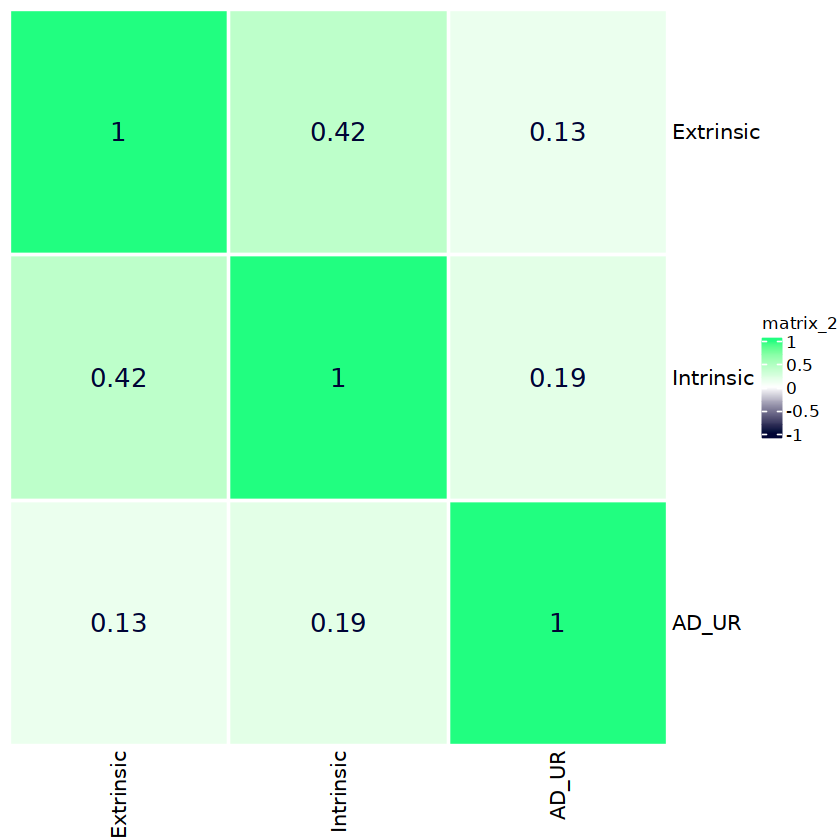

In [11]:
# Plotting -- select columns 
df <- phyper
rownames(df) <- df$celltype
df <- df[,-1]
#df <- df[, which(grepl("AD", names(df), ignore.case = TRUE))]
df <- df[,c('pos0_AD','neg0_AD','pos24_AD','neg24_AD','AD_UR')]
     
# BH Multiple hypothesis correction 
pvals <- as.vector(as.matrix(df))  # Convert to a vector
pvals_adj <- p.adjust(pvals, method = "BH", n = length(pvals))  # Adjust all p-values at once
df <- as.data.frame(matrix(pvals_adj, nrow = nrow(df), ncol = ncol(df),
                               dimnames = list(rownames(df), colnames(df))))
# Convert pval to -log10
df = -log10(df)
df[] <- lapply(df, function(x) as.numeric(gsub("Inf", 300, x)))

# Combine pos+neg columns 
df$Intrinsic <- ifelse(df$pos24_AD > df$neg24_AD, 
                    df$pos24_AD, (-1*df$neg24_AD))
df$Systemic <- ifelse(df$pos0_AD > df$neg0_AD, 
                    df$pos0_AD, (-1*df$neg0_AD))
df$AD_UR <- (-1*df$AD_UR)          

df <- df[,c('Systemic','Intrinsic','AD_UR')]             
#pdf(paste0(PLOTDIR, 'Heatmap.Anderson_celltype_phyper_AD.pdf'), width = 4, height = 5)
library(ComplexHeatmap)
Heatmap(df, cluster_rows = F, cluster_columns = F,
        col = colorRamp2(c(-50, 0, 50), c("#000435", "#FFFFFF", "#21FE80")),
        cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            if(abs(df[i, j]) > 1.5) {
                grid.text('*', x, y, gp = gpar(col = "white", fontsize = 15))
            }
        })
#dev.off()

               
#pdf(paste0(PLOTDIR, 'Heatmap.Anderson_phyper_cor_AD.pdf'), width = 3, height = 4)               
cor_matrix <- cor(df)
h1 <- Heatmap(cor_matrix, cluster_rows = F, cluster_columns = F,
              col = colorRamp2(c(-1, 0, 1), c("#000435", "#FFFFFF", "#21FE80")),
       cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            grid.text(round(cor_matrix[i, j], 2), x, y, gp = gpar(fontsize = 15, col = "#000435"))
        })
draw(h1)
#dev.off()

In [12]:
# Load necessary library
#install.packages("VennDiagram")  # If not installed
library(VennDiagram)

# Define sets
Full_Overlap <- rownames(df[df$AD_UR < -1.5 & df$Systemic < -1.5 & df$Intrinsic < -1.5,])
Systemic_Overlap <- rownames(df[df$AD_UR < -1.5 & df$Systemic < -1.5,])
Intrinsic_Overlap <- rownames(df[df$AD_UR < -1.5 & df$Intrinsic < -1.5,])
Systemic_Intrinsic_Overlap <- rownames(df[df$Systemic < -1.5 & df$Intrinsic < -1.5,])
AD_UR_negative <- rownames(df[df$AD_UR < -1.5,])
Systemic <- rownames(df[df$Systemic < -1.5,])
Intrinsic <- rownames(df[df$Intrinsic < -1.5,])

pdf(paste0(PLOTDIR, 'Venn.Anderson_celltype_phyper_AD.pdf'), width = 6, height = 6) 
# Create Venn Diagram without intersections between Systemic and Intrinsic
venn.plot <- draw.triple.venn(
  area1 = length(Systemic),  # Systemic
  area2 = length(AD_UR_negative),    # AD_UR negative
  area3 = length(Intrinsic),  # Intrinsic
  n12 = length(Systemic_Overlap), # Only Systemic & AD_UR Negative overlap
  n13 = length(Systemic_Intrinsic_Overlap),  
  n23 = length(Intrinsic_Overlap),  # Only Intrinsic & AD_UR Negative overlap
  n123 = length(Full_Overlap),  # intersection between all three
  category = c("Negative Systemic", "AD Depletion", "Negative Intrinsic"),
  fill = c("#FFFFFF","#000435", "#21FE80"),
  alpha = 0.5,
  cat.col = c("black", "black", "black"),
  cex = 1.2,
  cat.cex = 1.5
)
# Add text labels for cell types inside each section
grid.text(paste(Systemic[!Systemic %in% c(Systemic_Intrinsic_Overlap,Systemic_Overlap)], collapse="\n"), x = 0.2, y = 0.3, gp=gpar(fontsize=15))
grid.text(paste(Intrinsic[!Intrinsic %in% c(Systemic_Intrinsic_Overlap,Intrinsic_Overlap)], collapse="\n"), x = 0.5, y = 0.8, gp=gpar(fontsize=15))
grid.text(paste(AD_UR_negative[!AD_UR_negative %in% c(Intrinsic_Overlap, Systemic_Overlap)], collapse="\n"), x = 0.8, y = 0.3, gp=gpar(fontsize=15))
#grid.text(paste(Systemic_Overlap, collapse="\n"), x = 0.5, y = 0.5, gp=gpar(fontsize=15))
grid.text(paste(Intrinsic_Overlap[!Intrinsic_Overlap %in% Full_Overlap], collapse="\n"), x = 0.7, y = 0.5, gp=gpar(fontsize=15))
grid.text(paste(Systemic_Intrinsic_Overlap[!Systemic_Intrinsic_Overlap %in% Full_Overlap], collapse="\n"), x = 0.3, y = 0.5, gp=gpar(fontsize=15))
grid.text(paste(Full_Overlap, collapse="\n"), x = 0.5, y = 0.5, gp=gpar(fontsize=15))
# Display plot
grid.draw(venn.plot)
dev.off()

Loading required package: futile.logger



pdf 
  2

In [188]:
# Plotting -- select columns 
df <- phyper
df <- df[df$celltype != 'Ex-NRGN',]
rownames(df) <- df$celltype
df <- df[,-1]
df <- df[, which(grepl("AD", names(df), ignore.case = TRUE))]
#df <- df[,c('can_sen_AD', 'sen_init_AD','sen_resp_AD','dna_damage_AD','AD_UR')]     
# BH Multiple hypothesis correction 
pvals <- as.vector(as.matrix(df))  # Convert to a vector
pvals_adj <- p.adjust(pvals, method = "BH", n = length(pvals))  # Adjust all p-values at once
df <- as.data.frame(matrix(pvals_adj, nrow = nrow(df), ncol = ncol(df),
                               dimnames = list(rownames(df), colnames(df))))
# Convert pval to -log10
df = -log10(df)
df[] <- lapply(df, function(x) as.numeric(gsub("Inf", 300, x)))
            
pdf(paste0(PLOTDIR, 'Heatmap.Anderson_celltype_phyper_dd_sen_AD.pdf'), width = 5, height = 5)
library(ComplexHeatmap)
Heatmap(df, cluster_rows = F, cluster_columns = F,
        col = c("#000435", "#FFFFFF", "#21FE80"),
        cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            if(abs(df[i, j]) > 1.5) {
                grid.text('*', x, y, gp = gpar(col = "white", fontsize = 15))
            }
        })
dev.off()

pdf(paste0(PLOTDIR, 'Heatmap.Anderson_phyper_cor_dd_sen_AD.pdf'), width = 8, height = 8)               
cor_matrix <- cor(df)
h1 <- Heatmap(cor_matrix, cluster_rows = T, cluster_columns = T,
              col = colorRamp2(c(-1, 0, 1), c("#000435", "#FFFFFF", "#21FE80")),
       cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            grid.text(round(cor_matrix[i, j], 2), x, y, gp = gpar(fontsize = 15, col = "#000435"))
        })
draw(h1)
dev.off()              

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


pdf 
  2

pdf 
  2